# Exploración de dependencias de servicio social
TecNM Acapulco · Análisis de Datos. Ejecutar desde la carpeta `notebooks/`.

In [1]:
import sys; sys.path.append("..")
import matplotlib.pyplot as plt, pandas as pd
from app import datos
pd.set_option("display.width", 140, "display.max_colwidth", 60)
df = datos.cargar_dependencias()
print(f"{len(df)} sedes de {df['id'].nunique()} dependencias")
print("Problemas de validación:", datos.validar(df) or "ninguno")

35 sedes de 30 dependencias
Problemas de validación: ninguno


## 1. Cobertura de los datos
Qué tan completo está cada campo (fracción de dependencias con dato).

In [2]:
dep = df.drop_duplicates("id")
campos = ["area", "carreras", "modalidad", "plazas", "horario", "requisitos", "duracion", "contacto", "convenio"]
dep[campos].notna().mean().round(2).to_frame("completo").T

,area,carreras,modalidad,plazas,horario,requisitos,duracion,contacto,convenio
completo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Dispersión geográfica y valores atípicos
Distancia de cada sede al centro de Acapulco; atípico = fuera de Q3 + 1.5·IQR.

In [3]:
g = datos.con_atipicas(df)
print(g["distancia_centro_km"].describe().round(1).to_string())
g.loc[g["atipica"], ["etiqueta", "distancia_centro_km"]].sort_values("distancia_centro_km", ascending=False)

count    35.0
mean     11.4
std      19.0
min       0.8
25%       4.3
50%       7.0
75%       8.6
max      85.3


,etiqueta,distancia_centro_km
3,Comisión para la Protección contra Riesgos Sanitarios de...,85.33
4,Instituto de Capacitación para el Estado de Guerrero,84.19
13,H. Ayuntamiento Municipal Constitucional de Coyuca de Be...,33.15


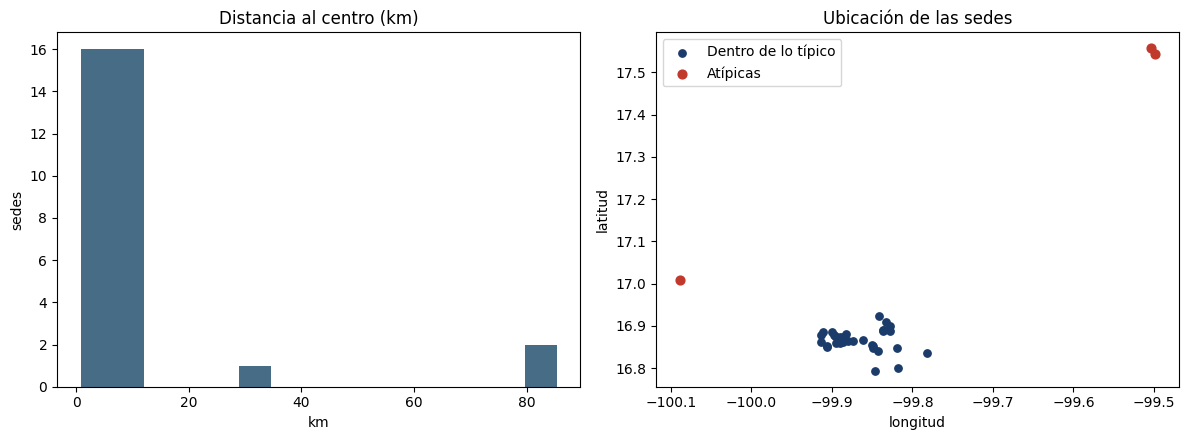

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].hist(g["distancia_centro_km"], bins=15, color="#466c86"); ax[0].set(title="Distancia al centro (km)", xlabel="km", ylabel="sedes")
n = g[~g["atipica"]]; a = g[g["atipica"]]
ax[1].scatter(n["lon"], n["lat"], c="#1b3b6b", s=28, label="Dentro de lo típico")
ax[1].scatter(a["lon"], a["lat"], c="#c0392b", s=40, label="Atípicas")
ax[1].set(title="Ubicación de las sedes", xlabel="longitud", ylabel="latitud"); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Zona urbana de Acapulco (sin atípicas)
Acercamiento a las sedes típicas, donde viven la mayoría de los alumnos.

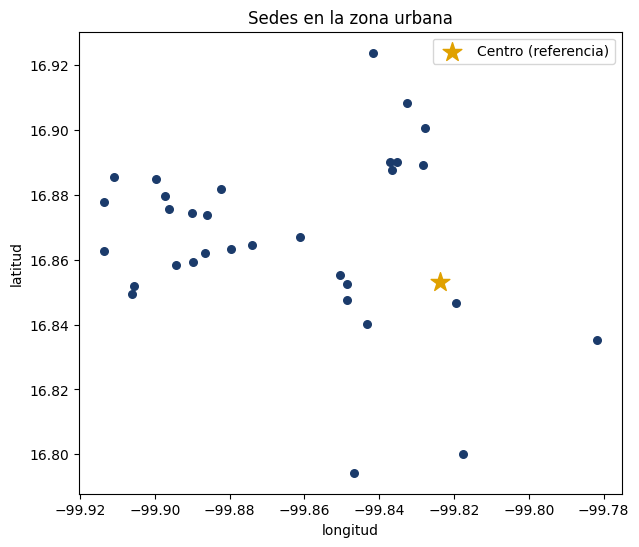

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(n["lon"], n["lat"], c="#1b3b6b", s=30); ax.scatter(*datos.CENTRO[::-1], marker="*", s=200, c="#e0a100", label="Centro (referencia)")
ax.set(title="Sedes en la zona urbana", xlabel="longitud", ylabel="latitud"); ax.legend(); plt.show()

## 4. Cobertura desde distintos puntos de la ciudad
Puntos de **ejemplo aproximados** (no son datos reales de alumnos): sirven para probar el método. Se reemplazarán con la encuesta a compañeros.

In [6]:
ejemplos = {"Zona Diamante": (16.81, -99.80), "Costera": (16.857, -99.875), "Renacimiento": (16.89, -99.86), "Coloso": (16.845, -99.81)}
filas = []
for nombre, (la, lo) in ejemplos.items():
    c = datos.cercanas(df, la, lo, None)
    filas.append({"punto": nombre, "mas_cercana": c.iloc[0]["etiqueta"][:45], "km_mas_cercana": c.iloc[0]["distancia_km"],
                  "sedes_a_menos_de_5km": int((c["distancia_km"] < 5).sum()), "mediana_5_mas_cercanas": c["distancia_km"].head(5).median()})
pd.DataFrame(filas)

,punto,mas_cercana,km_mas_cercana,sedes_a_menos_de_5km,mediana_5_mas_cercanas
0,Zona Diamante,Promotora Turística de Guerrero,2.18,3,4.58
1,Costera,Secretaría de Educación Guerrero Región Acapu,0.85,21,1.37
2,Renacimiento,"Centro de Estudios Tecnológicos, Industrial y",2.45,21,2.55
3,Coloso,CECyTEC Plantel 04 El Coloso,1.04,6,3.57


## Siguiente
- Completar `data/faltantes.csv` (carreras y áreas) para analizar cobertura **por carrera**.
- Reemplazar los puntos de ejemplo con las zonas reales de la encuesta.
- Comparar línea recta contra distancia por calles (OSRM).